# Importing the necessary libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity 
from surprise import Dataset,Reader,SVD,accuracy
from surprise.model_selection import train_test_split  

In [2]:
import sys 
print(sys.executable)

c:\Users\LENOVO\anaconda3\envs\ml\python.exe


# Doing Data Cleaning

In [3]:
name=pd.read_csv(r"C:\Users\LENOVO\Desktop\code\project ideas\anime recommendation system\Data\anime.csv")
rating=pd.read_csv(r"C:\Users\LENOVO\Desktop\code\project ideas\anime recommendation system\Data\rating.csv")

In [4]:
name.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [5]:
rating.head()

,user_id,anime_id,rating
0,1,20,-1
1,1,24,-1
2,1,79,-1
3,1,226,-1
4,1,241,-1


Checking for duplicates 

In [6]:
name.duplicated().sum()

0

In [7]:
rating.duplicated().sum()
rating.drop_duplicates(inplace=True)
rating.duplicated().sum()

0

In [8]:
name.dropna(subset=['genre'], inplace=True)   

In [9]:
name.isnull().sum()

anime_id      0
name          0
genre         0
type         22
episodes      0
rating      215
members       0
dtype: int64

In [10]:
name['rating'].fillna(name['rating'].median(),inplace=True)
name['type'].fillna('Unknown',inplace=True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25032\1279467387.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  name['rating'].fillna(name['rating'].median(),inplace=True)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25032\1279467387.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a c

In [11]:
name.isnull().sum()

anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

In [12]:
name['genre_list'] = name['genre'].dropna().apply(
    lambda x: [g.strip() for g in x.split(',')]
)

In [13]:
unique_genres = name['genre_list'].explode().nunique()
print(f"Number of unique genres: {unique_genres}")

Number of unique genres: 43


# Eda

## 1)User Behaviour Analysis

### “Can we realistically personalize recommendations for most users, or will most users get generic suggestions?”

In [14]:
user_rating_count= rating.groupby('user_id')['rating'].count().reset_index()
print(user_rating_count.head())
user_rating_count.columns=['user_id','rating_count']

   user_id  rating
0        1     153
1        2       3
2        3      94
3        4      52
4        5     467


In [15]:
percentile25=user_rating_count['rating_count'].quantile(0.25)
percentile50=user_rating_count['rating_count'].quantile(0.50)
percentile75=user_rating_count['rating_count'].quantile(0.75)
print(f"25th Percentile: {percentile25}")
print(f"50th Percentile: {percentile50}")
print(f"75th Percentile: {percentile75}")


25th Percentile: 18.0
50th Percentile: 57.0
75th Percentile: 136.0


Since 85 percent of users have rated 18 or more anime, we will use 20 ratings as a threshold wheter that user data can be used for personalized recommendations effectively. This means that the majority of users have enoough data to receive personalized recommendations,while a small minority with fewer ratings may receive more generic suggestions. This approach allows us to tailor recommendations for most users while acknowledging that some may not have sufficient data for personalization.

In [16]:
user_rating_count= rating.groupby('user_id')['rating'].count().reset_index()
user_rating_count.columns=['user_id','rating_count']
no_of_users_with_more_than_20_ratings = user_rating_count[user_rating_count['rating_count'] > 20].shape[0]
no_of_users_with_more_than_20_ratings / user_rating_count.shape[0] * 100

72.81779228728831

### CONCLUSION:
"The median user has rated 57 anime, and 75% of users have rated at least 18 — providing sufficient signal for collaborative filtering across the majority of the userbase. We set our minimum threshold at 20, which retains 75% of users while filtering out profiles too sparse to generate reliable recommendations."

###  How do users rate? Are they generous or critical?

<Axes: xlabel='rating', ylabel='count'>

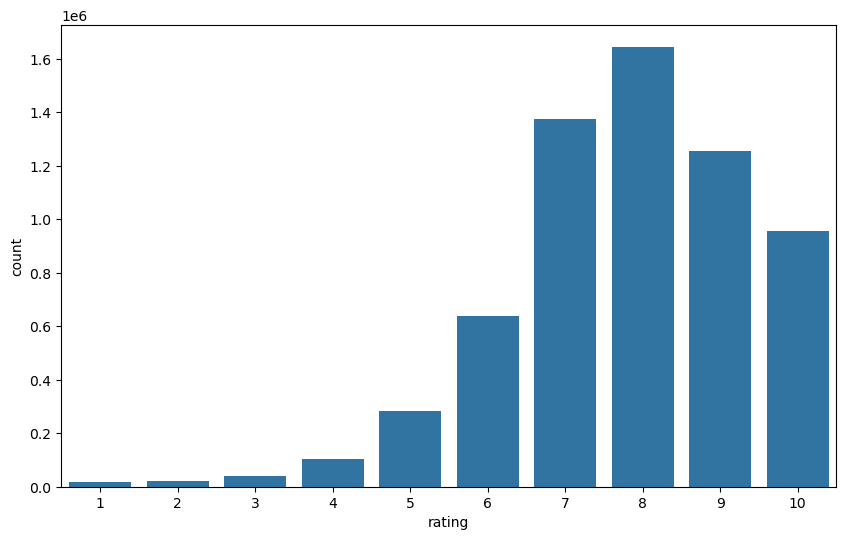

In [17]:
rating_non_zero = rating[rating['rating'] > 0]
plt.figure(figsize=(10,6))
sns.countplot(x='rating',data=rating_non_zero)

### Conclusion:
"AniList users are generous raters. The distribution is heavily right skewed with the mass of ratings concentrated between 7 and 9. Ratings below 6 are rare, suggesting users either rate positively or don't rate at all — they abandon rather than criticize. This compresses the effective rating scale and means similarity calculations should treat high-end differences with more sensitivity."

### Diffrence between heavy raters and light raters 

In [18]:
heavy_raters=user_rating_count[user_rating_count['rating_count']>200]
casual_raters=user_rating_count[(user_rating_count['rating_count']<50)&(user_rating_count['rating_count']>20)]

In [19]:
print('No of heavy raters:',heavy_raters.shape[0])
print('No of casual raters:',casual_raters.shape[0])
print("AVG rating given by heavy raters:",rating[rating['user_id'].isin(heavy_raters['user_id'])]['rating'].mean())
print("AVG rating given by casual raters:",rating[rating['user_id'].isin(casual_raters['user_id'])]['rating'].mean())

No of heavy raters: 11193
No of casual raters: 14066
AVG rating given by heavy raters: 5.905608530536478
AVG rating given by casual raters: 6.68743740118048


"Heavy raters average 5.9 versus 6.7 for casual raters. While this appears to be a modest 0.8 point difference, it is significant within AniList's compressed rating culture where the effective scale runs from 7 to 10. A 5.9 average places heavy raters in critical territory by platform standards, while 6.7 sits around the platform average. This confirms meaningful rating scale drift between user segments."

In [20]:
print("Variance in rating given by heavy raters:",rating[rating['user_id'].isin(heavy_raters['user_id'])]['rating'].var())
print("Variance in rating given by casual raters:",rating[rating['user_id'].isin(casual_raters['user_id'])]['rating'].var())

Variance in rating given by heavy raters: 13.77695628295302
Variance in rating given by casual raters: 13.77459940709696


"Analysis of rating variance reveals near identical spread between heavy raters (13.78) and casual raters (13.77), confirming that the behavioral difference between segments is a systematic mean shift rather than a change in rating pattern. Heavy raters do not rate more consistently or erratically — they simply anchor lower across the board. This strengthens the case for per-user mean centering as the primary normalization strategy, directly addressing mean shift without distorting natural rating spread."

In [21]:
heavy_raters=heavy_raters.merge(rating, on='user_id')
casual_raters=casual_raters.merge(rating, on='user_id')

In [22]:
heavy_raters=heavy_raters.merge(name, on='anime_id')
casual_raters=casual_raters.merge(name, on='anime_id')

In [23]:
print(heavy_raters.columns)

Index(['user_id', 'rating_count', 'anime_id', 'rating_x', 'name', 'genre',
       'type', 'episodes', 'rating_y', 'members', 'genre_list'],
      dtype='object')


In [24]:
heavy_raters.drop(columns=['type','episodes', 'rating_y', 'members'],inplace=True)
casual_raters.drop(columns=['type','episodes', 'rating_y','genre', 'members'],inplace=True)

In [25]:
heavy_raters.rename(columns={'rating_x':'user_rating'}, inplace=True)
casual_raters.rename(columns={'rating_x':'user_rating'}, inplace=True)

In [26]:
heavy_raters_genre=heavy_raters.explode('genre_list')
casual_raters_genre=casual_raters.explode('genre_list')

In [27]:
heavy_raters_genre.head()

,user_id,rating_count,anime_id,user_rating,name,genre,genre_list
0,5,467,6,8,Trigun,"Action, Comedy, Sci-Fi",Action
0,5,467,6,8,Trigun,"Action, Comedy, Sci-Fi",Comedy
0,5,467,6,8,Trigun,"Action, Comedy, Sci-Fi",Sci-Fi
1,5,467,15,6,Eyeshield 21,"Action, Comedy, Shounen, Sports",Action
1,5,467,15,6,Eyeshield 21,"Action, Comedy, Shounen, Sports",Comedy


In [28]:
heavy_genre=heavy_raters_genre.groupby('genre_list').agg({'genre_list':'count'}).rename(columns={'genre_list':'count'}).reset_index()
casual_genre=casual_raters_genre.groupby('genre_list').agg({'genre_list':'count'}).rename(columns={'genre_list':'count'}).reset_index()

In [29]:
heavy_genre.sort_values(by='count', ascending=False).head(10)


,genre_list,count
3,Comedy,2103054
0,Action,1663284
25,Romance,1300771
6,Drama,1029218
8,Fantasy,1022644
27,School,1016896
38,Supernatural,980919
32,Shounen,961815
28,Sci-Fi,864724
1,Adventure,825601


In [30]:
heavy_genre.sort_values(by='count', ascending=False).head(10)
casual_genre.sort_values(by='count', ascending=False).head(10)

,genre_list,count
3,Comedy,232352
0,Action,218323
25,Romance,153362
6,Drama,153076
8,Fantasy,138367
38,Supernatural,135985
1,Adventure,125891
32,Shounen,124791
27,School,107004
28,Sci-Fi,96249


### Conclusion for genre analysis among heavy and light raters:
"Genre frequency analysis reveals no significant divergence between heavy and casual raters in terms of content preference. Both segments share identical top genres — Comedy, Action, Romance, Drama, Fantasy — in nearly the same ranking order. This suggests that genre preference is not what differentiates these two user segments. The meaningful difference lies in how they rate, not what they watch. This finding simplifies our modeling approach — user segmentation based on rating behavior requires mean centering correction but does not require separate genre-weighted models for each segment."

### CONCLUSION:

"Comparative analysis between heavy and casual raters reveals that the two segments are behaviorally similar but systematically different in rating calibration. While both groups show identical variance (~13.77) and consume the same top genres in the same order, heavy raters anchor significantly lower at 5.9 versus 6.7 for casual raters. Within AniList's compressed rating culture where the effective scale runs from 7 to 10, this gap places heavy raters in critical territory while casual raters sit around platform average. Genre preference shows no divergence between segments, confirming that the only meaningful difference is rating scale calibration. This justifies per-user mean centering as the sole normalization requirement — no segment specific genre weighting is needed."

### Data Concentration Risk Analysis

In [31]:
top_1_rating_count=user_rating_count['rating_count'].quantile(0.99)
top_users=user_rating_count[user_rating_count['rating_count']>top_1_rating_count]
print("Number of users in top 1%:",top_users.shape[0])
print("Concentration Risk:",top_users['rating_count'].sum()/user_rating_count['rating_count'].sum()*100)

Number of users in top 1%: 736
Concentration Risk: 9.406831763960287


### CONCLUSION:
Data concentration analysis reveals that the top 1% of users by rating volume account for 9.5% of total ratings — a proportional contribution indicating no significant concentration risk. Unlike many platform datasets where a small power user minority dominates signal generation, AniList's rating distribution is broadly spread across its userbase. This means our collaborative filtering model will learn from a representative cross section of users rather than being disproportionately shaped by a small group of power users."

## 2) Catalog Analysis

### Are ratings concentrated around a small fraction of the anime catalog, or spread across it? What percentage of total ratings do the top 1% of anime absorb?

In [32]:
top_1_ratedanime=name['members'].quantile(0.99)
top_anime=name[name['members']>top_1_ratedanime]
print("Number of anime in top 1%:",top_anime.shape[0])
print("Concentration Risk:",top_anime['members'].sum()/name['members'].sum()*100)

Number of anime in top 1%: 123
Concentration Risk: 23.422769802359436


### CONCLUSION:
"Catalog concentration analysis reveals that the top 1% of anime by member count — just 123 titles — account for 23.4% of total rating activity on the platform. This is more than twice the concentration observed on the user side (9.5%), indicating that the catalog has a far more severe distribution problem than the userbase. A disproportionate share of platform attention is absorbed by a small group of established titles, leaving the remaining 99% of the catalog competing for the remaining 76.6% of engagement. This concentration is the structural foundation of the popularity bias problem — a recommendation system trained on this data will inevitably learn to surface the same 123 titles repeatedly, regardless of what the broader catalog contains."

### Are lesser known titles actually worse, or just less seen?

<Axes: xlabel='members', ylabel='rating'>

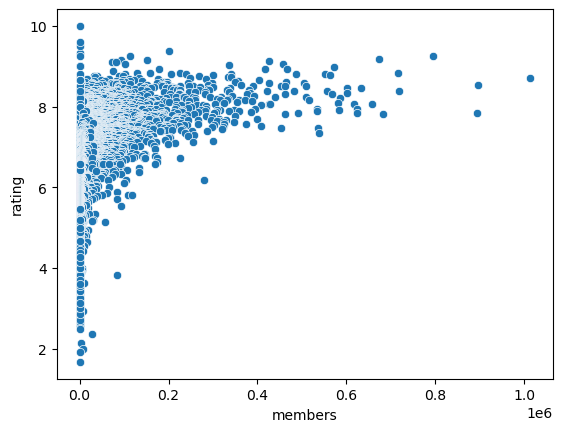

In [33]:
sns.scatterplot(x='members',y='rating',data=name)

### CONCLUSION:
"The relationship between member count and average rating reveals a pattern consistent with systematic popularity bias. Low member count anime show extreme score variance ranging from 1.5 to 10, reflecting genuine diversity in quality but also statistical noise from small sample sizes. High member count anime converge into a narrow band between 7.5 and 9.5 — not because popular anime are uniformly excellent, but because large rating volumes smooth variance and create an illusion of consistent quality. A standard recommendation system trained on this data will interpret this stability as a quality signal and surface popular titles preferentially, while dismissing niche titles as unreliable — regardless of their actual merit."

### How much of the catalog is effectively invisible?

(0.0, 3000.0)

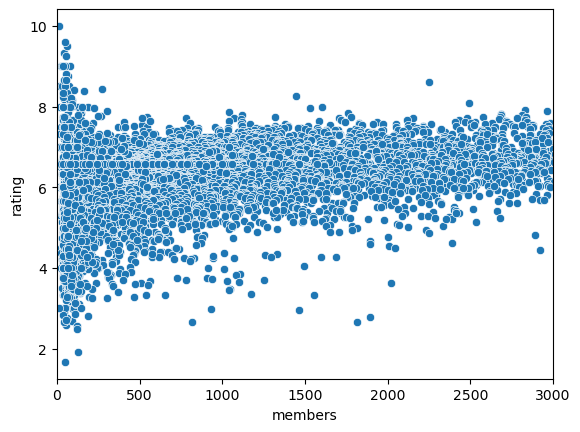

In [34]:
sns.scatterplot(x='members',y='rating',data=name)
plt.xlim(0,3000)

It's clear that when we go below 1000 members the anime is effectively invisible, as the ratings are volatile and recommendations system will not be able to learn to learn from them.

In [35]:
bottom_anime=name[name['members']<1000]
print("Number of anime with less than 1000 members:",bottom_anime.shape[0])
print("Percentage of anime which are effectively invisible:",bottom_anime.shape[0]/name.shape[0]*100)

Number of anime with less than 1000 members: 5297
Percentage of anime which are effectively invisible: 43.30444735120994


### CONCLUSION: 
"Visibility analysis reveals that 5,297 anime — 43% of the AniList catalog — fall below the 1,000 member threshold identified as the minimum for statistical reliability. These titles are effectively invisible to standard recommendation systems, not because of poor quality but because insufficient rating volume makes their scores unreliable and their collaborative filtering signal too weak to compete with established titles. Combined with the earlier finding that the top 1% of anime absorb 23.4% of all rating activity, this paints a clear picture of a platform where nearly half the catalog is structurally disadvantaged from the moment of release."

## 3) Bias Analysis


### Does popularity influence ratings in a way that distorts true quality, or are higher ratings simply a result of better anime attracting more users?

Checking the average rating of anime by dividing them into 3 groups based on their member count(niche,mid and popular)

In [36]:
print("Average rating of niche anime:",name[name['members']<name['members'].quantile(0.25)]['rating'].mean())
print("Average rating of mid anime:",name[(name['members']<name['members'].quantile(0.50))&(name['members']>name['members'].quantile(0.25))]['rating'].mean())
print("Average rating of popular anime:",name[name['members']>name['members'].quantile(0.75)]['rating'].mean())

Average rating of niche anime: 5.686841072596469
Average rating of mid anime: 6.144988550866863
Average rating of popular anime: 7.3835905820797905


Checking the median rating of anime by dividing them into 3 groups based on their member count(niche,mid and popular) to account the skewness of the ratings distribution.

In [37]:
print("Average rating of niche anime:",name[name['members']<name['members'].quantile(0.25)]['rating'].median())
print("Average rating of mid anime:",name[(name['members']<name['members'].quantile(0.50))&(name['members']>name['members'].quantile(0.25))]['rating'].median())
print("Average rating of popular anime:",name[name['members']>name['members'].quantile(0.75)]['rating'].median())

Average rating of niche anime: 5.71
Average rating of mid anime: 6.24
Average rating of popular anime: 7.405


It is found that the average and median rating of popular anime is higher than the niche and mid anime,which indicates that popularity does seem to have an influence in the ratings, but it is not clear whether this is due to better quality or bias in the ratings.Further analysis is needed to determine the extent of influence of popularity on ratings and wheter it distorts true quality or not.It is also noteworty that the diffrence between the rating of popular anime and niche anime is not only large but they also lie in diffrent segments as it was proved earlier that any anime rated below 6 is considered as a bad anime by the users, so the diffrence between the rating of popular anime and niche anime is not only large but also significant  as it's diffrence between a good anime and a bad anime

Checking the correlation coefficient between member count and average rating

In [38]:
corr=name['members'].corr(name['rating'])
print("Correlation Coeffiecient between member count and average rating:",corr)

Correlation Coeffiecient between member count and average rating: 0.38772927604466445


### CONCLUSION:
"Analysis reveals a systematic relationship between popularity and rating scores. Popular anime average 7.38 compared to 6.14 for mid tier and 5.69 for niche titles — a 1.7 point gap confirmed by median scores, ruling out outlier distortion. A Pearson correlation of 0.39 between member count and average rating confirms this relationship is consistent and not incidental. Critically, this gap is not merely numerical — within AniList's compressed rating culture where scores below 6 are considered poor by platform standards, popular anime sit comfortably in the above average range while niche anime are pushed into below average territory by default. Whether this reflects genuine quality differences or popularity driven score inflation cannot be determined from ratings data alone, but the systematic nature of the gap — consistent across mean, median, and correlation — strongly suggests popularity is a significant contributing factor. The bias correction layer in this recommendation system directly addresses this by applying a popularity penalty during recommendation ranking, ensuring niche titles are evaluated on relative merit rather than absolute score."

## 4) Genre Anlysis

###  is our catalog genuinely diverse or are we a shounen action platform pretending to have variety?

In [39]:
genre=name.explode('genre_list').groupby('genre_list').agg({'genre_list':'count'}).rename(columns={'genre_list':'count'}).reset_index()
genre['percentage']=genre['count']/genre['count'].sum()*100
genre.sort_values(by='count',ascending=False).reset_index(drop=True)

,genre_list,count,percentage
0,Comedy,4645,12.801433
1,Action,2845,7.840706
2,Adventure,2348,6.470994
3,Fantasy,2309,6.363511
4,Sci-Fi,2070,5.704837
5,Drama,2016,5.556015
6,Shounen,1712,4.718203
7,Kids,1609,4.434339
8,Romance,1464,4.034725
9,Slice of Life,1220,3.362271


Text(0.5, 1.0, 'Is the catalog dominated by a few genres or is it genuinely diverse?')

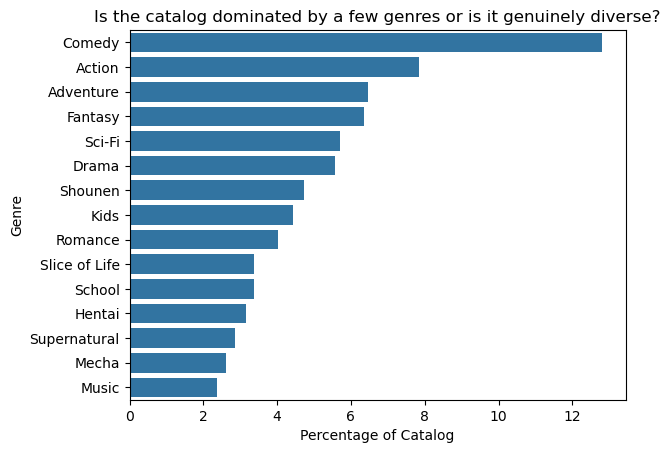

In [40]:
sns.barplot(y='genre_list',x='percentage',data=genre.sort_values(by='count',ascending=False).head(15))
plt.ylabel('Genre')
plt.xlabel('Percentage of Catalog')
plt.title("Is the catalog dominated by a few genres or is it genuinely diverse?")

### CONCLUSION:
"Genre frequency analysis across the full catalog reveals genuine diversity rather than genre dominance. Comedy leads at 12.8% followed by Action at 7.8% and Adventure at 6.5%, but the distribution is gradual with no sharp concentration cliff — the bottom half of genres each account for under 3% of the catalog. With 43 distinct genres represented, AniList cannot be characterized as a shounen action platform. The observed frequency differences likely reflect global anime production patterns rather than platform curation bias, as broadly appealing genres like Comedy and Action are inherently more produced by the industry. This finding shifts the diversity concern from catalog composition to recommendation output — the question is not whether diverse content exists on the platform, but whether it actually gets surfaced to users."
That last sentence is your bridge directly into question two. Clean transition.
Bar graph first, then question two?Sonnet 4.6

### does popularity have a genre preference?**

In [41]:
popular_genre=name.explode('genre_list').groupby('genre_list').agg({'members':'median'}).rename(columns={'members':'median_members'}).reset_index()
popular_genre=popular_genre.sort_values(by='median_members',ascending=False).reset_index(drop=True)
total_genre=name.explode('genre_list').groupby('genre_list').agg({'members':'sum'}).rename(columns={'members':'total_members'}).reset_index()
popular_genre=popular_genre.merge(total_genre, on='genre_list')
popular_genre

,genre_list,median_members,total_members
0,Thriller,55566.0,10133530
1,Harem,24393.0,19897828
2,Psychological,21648.0,17211633
3,Vampire,20300.0,6401806
4,Shoujo Ai,20294.0,1917870
5,Josei,19114.5,2213791
6,Supernatural,13727.0,57008004
7,Ecchi,13563.0,25013853
8,Romance,13208.0,65663654
9,Super Power,12732.0,22805793


### CONCLUSION:
"Analysis of genre popularity using both median and total member count reveals a striking divergence from catalog frequency distribution. Genres dominating the catalog — Comedy at 12.8%, Action at 7.8% — show surprisingly low median member counts of 2,745 and 4,678 respectively, indicating that most individual anime in these genres are relatively obscure despite the genre's overall prevalence. Conversely, genres like Thriller, Harem, and Psychological — underrepresented in the catalog — show median member counts exceeding 20,000, suggesting that when these genres do appear, they consistently attract substantial audiences. This confirms that popularity has a clear genre preference that diverges significantly from catalog composition. A recommendation system trained purely on accumulated rating signals will systematically favor Comedy and Action — not because users prefer them but because sheer volume of titles creates more training signal — while consistently underserving high engagement niche genres like Thriller and Psychological whose audiences are passionate but whose catalog presence is limited."

### Which genres have passionate but small audiences?

In [42]:
niche_anime=name[name['members']<name['members'].quantile(0.25)]
niche_genre=niche_anime.explode('genre_list').groupby('genre_list').agg({'rating':'mean','members':'median'}).rename(columns={'rating':'avg_rating'}).reset_index()
niche_genre=niche_genre.sort_values(by='avg_rating',ascending=False).reset_index(drop=True)
niche_genre

,genre_list,avg_rating,members
0,Josei,6.400000,170.0
1,Drama,6.313985,71.0
2,Police,6.295238,116.0
3,Historical,6.250748,85.5
4,Mystery,6.121786,118.5
5,School,6.073333,106.5
6,Martial Arts,6.037059,107.5
7,Psychological,6.006923,141.0
8,Seinen,5.998197,100.0
9,Samurai,5.978519,90.0


### CONCLUSION:
"Genre passion analysis identifies Josei, Drama, Police, Historical and Mystery as AniList's most underserved audiences — averaging above 6.1 ratings despite median member counts under 120. These genres have passionate followers whose content is structurally invisible to popularity driven recommendation systems. Notably, low member count alone doesn't indicate an underserved audience — Harem and Hentai sit at the bottom even within the niche tier, confirming that both low popularity and high rating must coexist to identify genuinely underserved genres. The bias correction layer will prioritize surfacing these genres whenever user history shows even weak affinity signals."

# 📊 EDA Findings — Executive Summary

---

## **Userbase**

- Highly engaged userbase  
  - Median user rated **57 anime**  
  - 75% of users rated **≥ 18 anime**

- Rating activity is well distributed  
  - Top 1% users contribute only **9.5% of total ratings**  
  - No significant power-user skew

- Calibration gap between user segments  
  - Heavy raters → avg rating **5.9**  
  - Casual raters → avg rating **6.7**

- Gap is a **mean shift, not behavioral difference**  
  - Similar genre preferences and variance  
  - Different rating baselines (anchoring effect)

---

## **Catalog**

- Structurally diverse  
  - **43 genres**, no dominant category  
  - Highest: Comedy at **12.8%**

- Visibility is highly concentrated  
  - Top 1% of anime → **23.4% of total rating activity**

- Large portion lacks reliable signals  
  - **43% (~5,297 titles)** have < 1,000 members  
  - Low exposure → low confidence, not necessarily low quality

- Rating stability depends on exposure  
  - High-member anime → **stable ratings (~7.5–9.5)**  
  - Low-member anime → **high variance**

- Key insight  
  → Larger audiences improve **rating reliability**, not necessarily quality

---

## **Popularity vs Rating**

- Ratings increase with popularity  
  - Niche: **5.69**  
  - Mid: **6.14**  
  - Popular: **7.38**

- Median follows same trend  
  → Difference is **not driven by outliers**

- Moderate positive correlation  
  - Pearson r ≈ **0.39**

- Difference is meaningful  
  - ~1.7 gap = **poor vs good anime boundary** in platform scale

- Interpretation  
  - Relationship is real and consistent  
  - Cause is unclear:
    - Selection effect (better anime become popular)  
    - Stability effect (ratings improve with more data)

- Conclusion  
  → Popularity should be treated as a **confidence signal**, not direct quality indicator

---

## **Genre Dynamics**

- Frequency ≠ popularity  
  - Comedy → most common (**12.8%**) but low engagement (~2,745 median members)  
  - Thriller → rare but highly engaged (~55,566 median members)

- Underserved high-quality segments  
  - Josei, Drama, Police, Historical, Mystery  
  - Avg rating > **6.1**, median members < **120**

- Not all niche = opportunity  
  - Harem, Hentai → low engagement + low ratings

- Key insight  
  → Opportunity exists where **quality + engagement coexist**, not just low exposure

---

## **Overall Takeaways**

- User engagement is strong → **collaborative filtering is viable**
- Ratings are usable but vary in reliability  
  → depend on **member count**
- Popularity strongly correlates with rating  
  → should be used as **confidence weighting**
- Catalog is diverse, but visibility is skewed  
  → many items lack sufficient exposure
- Genre demand and supply are misaligned  
  → potential for **better discovery systems**

# CONTENT BASED FILTERING

##  Feature Engineering: One Hot Encoding Genres

In [43]:
mlb = MultiLabelBinarizer()
genre_ohe = pd.DataFrame(
    mlb.fit_transform(name['genre_list']),
    columns=mlb.classes_,
    index=name.index
)
name = pd.concat([name, genre_ohe], axis=1)

In [44]:
name.head()

,anime_id,name,genre,type,episodes,rating,members,genre_list,Action,Adventure,...,Shounen Ai,Slice of Life,Space,Sports,Super Power,Supernatural,Thriller,Vampire,Yaoi,Yuri
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,"[Drama, Romance, School, Supernatural]",0,0,...,0,0,0,0,0,1,0,0,0,0
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665,"[Action, Adventure, Drama, Fantasy, Magic, Mil...",1,1,...,0,0,0,0,0,0,0,0,0,0
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262,"[Action, Comedy, Historical, Parody, Samurai, ...",1,0,...,0,0,0,0,0,0,0,0,0,0
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572,"[Sci-Fi, Thriller]",0,0,...,0,0,0,0,0,0,1,0,0,0
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266,"[Action, Comedy, Historical, Parody, Samurai, ...",1,0,...,0,0,0,0,0,0,0,0,0,0


### Quality Filter: Bayesian Adjusted Rating

In [45]:
similarity_matrix=cosine_similarity(genre_ohe)

In [46]:
similarity_matrix

array([[1.        , 0.18898224, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.18898224, 1.        , 0.28571429, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.28571429, 1.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 1.        , 1.        ,
        1.        ],
       [0.        , 0.        , 0.        , ..., 1.        , 1.        ,
        1.        ],
       [0.        , 0.        , 0.        , ..., 1.        , 1.        ,
        1.        ]])

In [47]:
genre_ohe

,Action,Adventure,Cars,Comedy,Dementia,Demons,Drama,Ecchi,Fantasy,Game,...,Shounen Ai,Slice of Life,Space,Sports,Super Power,Supernatural,Thriller,Vampire,Yaoi,Yuri
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,1,1,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12289,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12290,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12291,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12292,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Adding ratings after concluding bayesian average



In [48]:
name['baysian_rating']=(name['members']*name['rating']+1000*name['rating'].mean())/(name['members']+1000)

### Recommendation Function with Popularity Penalty

In [49]:
def get_recommendations(anime_title, top_n=10):
    
    # Get index
    anime_index = name[(name['name'].str.lower()) == anime_title.lower()].index[0]
    
    # Popularity threshold
    top_anime = name['members'].quantile(0.90)
    
    # Similarity scores
    similar = list(enumerate(similarity_matrix[anime_index]))
    similar_sorted = sorted(similar, key=lambda x: x[1], reverse=True)
    
    # Apply popularity penalty
    penalized = []
    for idx, score in similar_sorted:
        members = name['members'].iloc[idx]
        if members > top_anime:
            score -= 0.3  # softer penalty (0.5 was too aggressive)
        penalized.append((idx, score))
    
    penalized = sorted(penalized, key=lambda x: x[1], reverse=True)
    
    # 🎯 Greedy selection with diversity
    selected = []
    genre_count = {}
    
    for idx, score in penalized:
        
        if idx == anime_index:
            continue
        
        rating = name['baysian_rating'].iloc[idx]
        if rating < 6.5:
            continue
        
        genres = name['genre_list'].iloc[idx]
        
        # Check genre cap
        allow = True
        for g in genres:
            if genre_count.get(g, 0) >= 4:
                allow = False
                break
        
        if not allow:
            continue
        
        # Add anime
        selected.append(idx)
        
        # Update genre counts
        for g in genres:
            genre_count[g] = genre_count.get(g, 0) + 1
        
        if len(selected) == top_n:
            break
    
    # ⚠️ Fallback (if too strict)
    if len(selected) < top_n:
        for idx, score in penalized:
            if idx == anime_index or idx in selected:
                continue
            
            if name['baysian_rating'].iloc[idx] >= 6.5:
                selected.append(idx)
            
            if len(selected) == top_n:
                break
    
    # Return names
    return name['name'].iloc[selected].tolist()

In [50]:
get_recommendations("naruto")

['Boruto: Naruto the Movie - Naruto ga Hokage ni Natta Hi',
 'Naruto x UT',
 'Naruto Shippuuden: Sunny Side Battle',
 'Naruto Soyokazeden Movie: Naruto to Mashin to Mitsu no Onegai Dattebayo!!',
 'Natsume Yuujinchou Go',
 'Mushishi Zoku Shou: Suzu no Shizuku',
 'Girls und Panzer der Film',
 'Mushishi Zoku Shou: Odoro no Michi',
 'Doukyuusei (Movie)',
 'Ashita no Joe 2']

### Due to the popularity bias penality there was -0.5 penality added to top 20 percentile anime to give more chance for niche anime to be recommended and to avoid the popularity bias problem

## Collaborative Filtering

### User-Anime Rating Matrix

In [51]:
rating.duplicated().sum()

0

In [52]:
user_flipped=rating.pivot_table(index='user_id', columns='anime_id', values='rating',aggfunc='mean').fillna(0)


### Data Formatting for Surprise

In [53]:
rating.head()

,user_id,anime_id,rating
0,1,20,-1
1,1,24,-1
2,1,79,-1
3,1,226,-1
4,1,241,-1


In [54]:
user=rating[rating['rating']>0]
user.head()

,user_id,anime_id,rating
47,1,8074,10
81,1,11617,10
83,1,11757,10
101,1,15451,10
153,2,11771,10


###  Train-Test Split

In [55]:
reader = Reader(rating_scale=(1, 10))
data=Dataset.load_from_df(user,reader)
train,test=train_test_split(data,test_size=0.2)

### SVD Model Training

In [56]:
svd=SVD()
model=svd.fit(train)
predictions=model.test(test)

### Model Evaluation: RMSE 

In [57]:
score=accuracy.rmse(predictions)
print("RMSE:",score)

RMSE: 1.1324
RMSE: 1.1324306080106978


### Recommendation Function with Popularity Penalty

In [58]:
def get_collaborative_recommendations(user_id, top_n=10):
    watched = user[user['user_id'] == user_id]['anime_id'].tolist()
    not_watched = name[~name['anime_id'].isin(watched)]['anime_id'].tolist()
    top_anime = name['members'].quantile(0.90)
    scores = []
    for i in not_watched:
        pred = model.predict(user_id, i)
        scores.append(pred)
    penalized = []
    for pred in scores:
        est = pred.est
        if name[name['anime_id'] == int(pred.iid)]['members'].values[0] > top_anime:
            est -= 0.5
        penalized.append((pred.iid, est))
    similar_sorted = sorted(penalized, key=lambda x: x[1], reverse=True)
    top_scores = similar_sorted[:top_n]
    recommended_anime_ids = [int(iid) for iid, est in top_scores]

    # Genre diversity enforcement
    genre_freq = {}
    for anime_id in recommended_anime_ids:
        genre = name[name['anime_id'] == anime_id]['genre_list'].values[0][0]
        genre_freq[genre] = genre_freq.get(genre, 0) + 1

    dominant_genres = {g: c for g, c in genre_freq.items() if c > 4}

    if dominant_genres:
        # Find excess anime to remove
        to_remove = []
        genre_seen = {}
        for anime_id in recommended_anime_ids:
            genre = name[name['anime_id'] == anime_id]['genre_list'].values[0][0]
            if genre in dominant_genres:
                genre_seen[genre] = genre_seen.get(genre, 0) + 1
                if genre_seen[genre] > 4:
                    to_remove.append(anime_id)

        # Remove excess
        for anime_id in to_remove:
            recommended_anime_ids.remove(anime_id)

        # Find substitutes
        substitutes = name[
            (~name['anime_id'].isin(recommended_anime_ids)) &
            (~name['anime_id'].isin(watched)) &
            (name['baysian_rating'] >= 6.5) &
            (~name['genre_list'].apply(lambda x: x[0] if x else None).isin(dominant_genres))
        ].sort_values('baysian_rating', ascending=False)

        substitute_ids = substitutes['anime_id'].tolist()[:len(to_remove)]
        recommended_anime_ids.extend(substitute_ids)

    result = name.set_index('anime_id').loc[recommended_anime_ids]['name'].tolist()
    return result

In [59]:
names=get_collaborative_recommendations(1)
print(names)

['Major S6', 'Kuroshitsuji', 'Elfen Lied', 'Higurashi no Naku Koro ni Kaku: Outbreak', 'Clannad', 'Fairy Tail', 'Major S4', 'Koe no Katachi', 'Gintama°: Aizome Kaori-hen', 'Major S3']


In [60]:
user_rating_count

,user_id,rating_count
0,1,153
1,2,3
2,3,94
3,4,52
4,5,467
...,...,...
73510,73512,13
73511,73513,33
73512,73514,1
73513,73515,196


## Hybrid Recommendation System

In [ ]:
user_id = int(input("Enter user Id for recommendations:"))
user_rating_count = user[user['user_id'] == user_id].shape[0]
top_anime_title = name[name['anime_id'].isin(
    user[user['user_id'] == user_id].nlargest(1, 'rating')['anime_id']
)]['name'].values[0]
if user_rating_count < 20:
    content_results = get_recommendations(top_anime_title)
    final_scores = {anime: (10 - i) for i, anime in enumerate(content_results)}
elif 20 <= user_rating_count <= 57:
    collab_results = get_collaborative_recommendations(user_id)
    content_results = get_recommendations(top_anime_title)
    collab_scores = {anime: (10 - i) for i, anime in enumerate(collab_results)}
    content_scores = {anime: (10 - i) for i, anime in enumerate(content_results)}
    all_anime = set(collab_scores.keys()) | set(content_scores.keys())
    final_scores = {anime: 0.7 * collab_scores.get(anime, 0) + 
                   0.3 * content_scores.get(anime, 0) for anime in all_anime}

else:
    collab_results = get_collaborative_recommendations(user_id)
    content_results = get_recommendations(top_anime_title)
    collab_scores = {anime: (10 - i) for i, anime in enumerate(collab_results)}
    content_scores = {anime: (10 - i) for i, anime in enumerate(content_results)}
    all_anime = set(collab_scores.keys()) | set(content_scores.keys())
    final_scores = {anime: 0.9 * collab_scores.get(anime, 0) + 
                   0.1 * content_scores.get(anime, 0) for anime in all_anime}

final_recommendations = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)[:10]
print([anime for anime, score in final_recommendations])

['Berserk', 'Yojouhan Shinwa Taikei', 'Cowboy Bebop', 'Turn A Gundam', 'Ginga Tetsudou 999', 'Ginga Eiyuu Densetsu', 'Ghost in the Shell: Stand Alone Complex', 'Hotaru no Haka', 'Rain Town', 'Kimi to Boku. 2']


In [69]:
name.to_csv("anime_data.csv", index=False)


### Loading the SVD Model and one hot encoded genres matrix

In [66]:

#with open("model.pkl", "wb") as f:
#    pickle.dump(model, f)
#
## Save similarity matrix
#with open("similarity_matrix.pkl", "wb") as f:
#    pickle.dump(similarity_matrix, f)
#
# Save dataframe
with open("anime_data.pkl", "wb") as f:
    pickle.dump(user, f)